In [2]:
import tifffile 
import numpy as np
import h5py
from tifffile import imread 
import os
import sys
import re
import matplotlib.pyplot as plt
import pandas as pd

In [20]:

def tiff_to_h5(tiff_filepath, h5_filepath, dataset_name='data'):
    pass
    # Read TIFF file
    tiff_data = tifffile.imread(tiff_filepath)
    reshaped_image = np.transpose(tiff_data, (1, 2, 3, 0))  # This reshapes the image to C,X,Y,Z. It might vary depending on your tiff file shape.
    print(f"TIFF file {tiff_filepath} reshaped")

    # Create HDF5 file
    with h5py.File(h5_filepath, 'w') as h5_file:
        # Create dataset in HDF5 file
        # print(h5_filepath)
        h5_file.create_dataset(dataset_name, data=reshaped_image)
    print(f"Conversion complete for {tiff_filepath}")
    
def process_folders(root_folder):
    output_folder = os.path.join(root_folder, "raw H5 files")
    os.makedirs(output_folder, exist_ok=True)

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)
        if os.path.isdir(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(".tif") or file_name.endswith(".tiff"):
                    # Match hyb and pos numbers
                    hyb_match = re.search(r'hyb_(\d+)_pos(\d+)', file_name)
                    if hyb_match:
                        hyb_number = int(hyb_match.group(1))
                        pos_number = hyb_match.group(2)
                        h5_filename = f"hyb_{hyb_number:03d}_pos{pos_number}.h5"
                        pos_folder = os.path.join(output_folder, f'pos{pos_number}')
                        os.makedirs(pos_folder, exist_ok=True)

                        tiff_filepath = os.path.join(folder_path, file_name)
                        h5_filepath = os.path.join(pos_folder, h5_filename)
                        tiff_to_h5(tiff_filepath, h5_filepath)
                    else:
                        print(f"Filename {file_name} doesn't match expected format, skipping.")

if __name__ == "__main__":
    root_folder =r"C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\20250125_MG2_Pool1_pos1"# Update this path to your root folder
    process_folders(root_folder)
    print("All conversions completed.")


TIFF file G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_0_pos0.tif reshaped
Conversion complete for G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_0_pos0.tif
TIFF file G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_10_pos0.tif reshaped
Conversion complete for G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_10_pos0.tif
TIFF file G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_11_pos0.tif reshaped
Conversion complete for G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_11_pos0.tif
TIFF file G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_12_pos0.tif reshaped
Conversion complete for G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_12_pos0.tif
TIFF file G:\Data\malemarkers\processed\MG1_Pool1_20231109\TiffAdjusted2.0\pos0\hyb_13_pos0.tif reshaped
Conversion complete for G:\Data\malem

In [4]:
#Single folder processing
def tiff_to_h5(tiff_filepath, h5_filepath, dataset_name='data'):
    # Read TIFF file
    tiff_data = tifffile.imread(tiff_filepath)
    reshaped_image = np.transpose(tiff_data, (1, 2, 3, 0))  # This reshapes the image to C,X,Y,Z. It might vary depending on your tiff file shape.
    print(f"TIFF file {tiff_filepath} reshaped")

    # Create HDF5 file
    with h5py.File(h5_filepath, 'w') as h5_file:
        # Create dataset in HDF5 file
        h5_file.create_dataset(dataset_name, data=reshaped_image)
    print(f"Conversion complete for {tiff_filepath}")

def process_folder(folder_path):
    output_folder = os.path.join(folder_path, "raw H5 files")
    os.makedirs(output_folder, exist_ok=True)

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".tif") or file_name.endswith(".tiff"):
            tiff_filepath = os.path.join(folder_path, file_name)
            
            # Modify filename to include leading zeros in the hyb number
            parts = file_name.split('_')
            hyb_number = parts[1]  # Assuming 'Hyb' is always at the first position
            hyb_number_with_leading_zeros = f"{int(hyb_number):03}"  # Convert to integer and back to string with leading zeros
            parts[1] = hyb_number_with_leading_zeros
            modified_file_name = '_'.join(parts)
            
            h5_filename = modified_file_name.rsplit('.', 1)[0] + '.h5'
            h5_filepath = os.path.join(output_folder, h5_filename)
            tiff_to_h5(tiff_filepath, h5_filepath)

if __name__ == "__main__":
    folder_path = r"C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1"# Update this path to your specific folder
    process_folder(folder_path)
    print("All conversions completed.")

TIFF file C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_0_pos1.tif reshaped
Conversion complete for C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_0_pos1.tif
TIFF file C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_10_pos1.tif reshaped
Conversion complete for C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_10_pos1.tif
TIFF file C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_11_pos1.tif reshaped
Conversion complete for C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_11_pos1.tif
TIFF file C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_12_pos1.tif reshaped
Conversion complete for C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_12_pos1.tif
TIFF file C:\Users\josed\OneDrive\Documents\DATA\Zadjusted\adjusted_tiff\pos1\hyb_13_pos1.tif reshaped
Conversion complete for C:\Users\josed\OneDrive\Documen

In [33]:
file1 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos0.tif"
tiff1 =imread(file1)


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x19d4d56c440>)

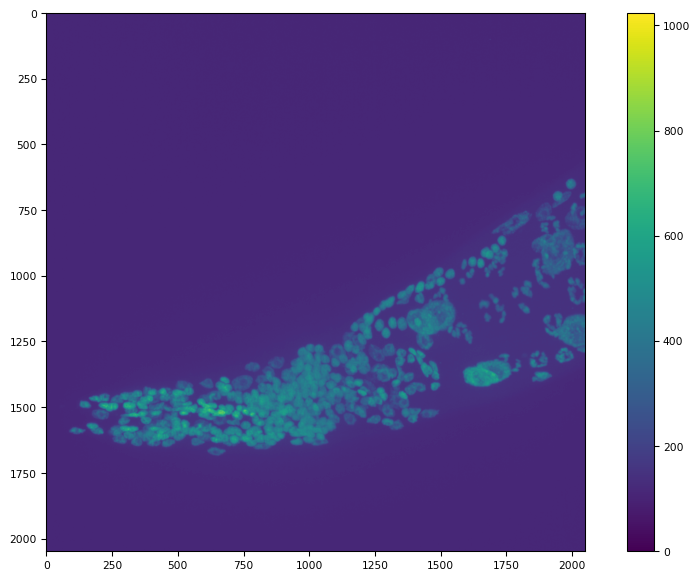

In [34]:
dapi1 = tiff1[:,2,:,:]
MIP1 = np.max(dapi1, axis = 0)
tifffile.imshow(MIP1)

In [6]:
channel_sums1 = np.sum(tiff1[:,:2,:,:], axis = (0, 2,3))

## 12

In [44]:
len_x12 = 2684
len_y12 = 3746

In [35]:
file2 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos1.tif"
tiff2= imread(file2)


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x19d4fa91070>)

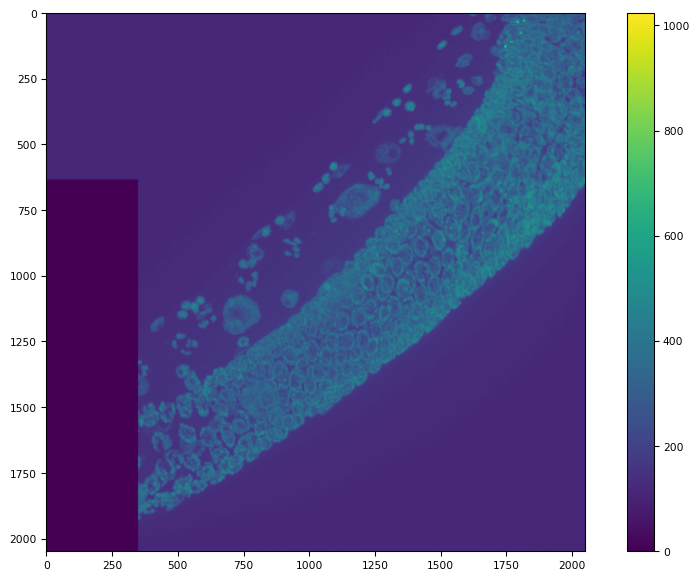

In [45]:
dapi2 = tiff2[:,2,:,:]
MIP2 = np.max(dapi2, axis = 0)
MIP2[len_x12-4096:,:4096-len_y12] = 0

tifffile.imshow(MIP2)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x19d50edf1d0>)

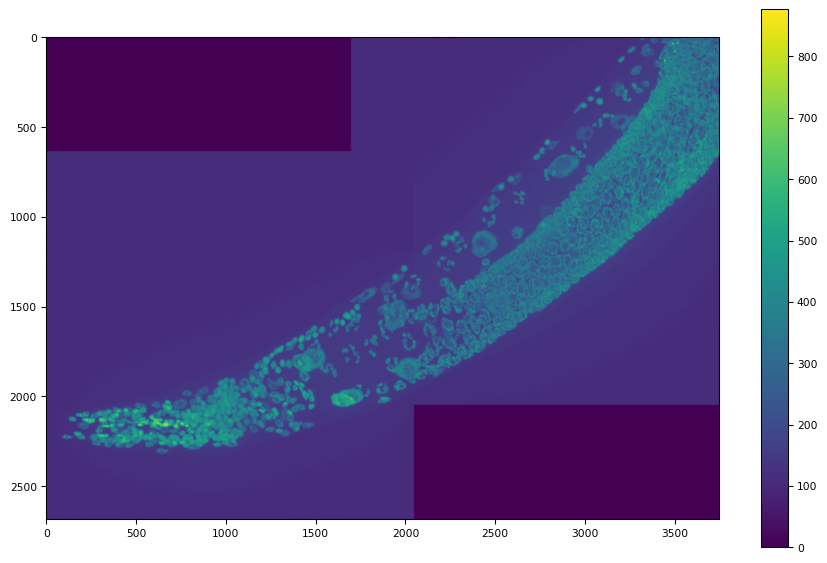

In [49]:
test12 = np.zeros((len_x12,len_y12))

test12[:2048,test12.shape[1]-2048:] = MIP2
test12[len_x12-4096 + 2048:,:2048] = MIP1
tifffile.imshow(test12)

In [10]:
tiff2_trimmed = tiff2.copy()
tiff2_trimmed[:,:,len_x12-4096:,:4096-len_y12] = 0

In [11]:
channel_sums2 = np.sum(tiff2_trimmed[:,:2,:,:], axis = (0, 2,3))

In [12]:
del tiff1

## 23

In [13]:
file3 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos2.tif"
tiff3= imread(file3)


In [14]:
len_x23 = 3512
len_y23 = 3611

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22661859410>)

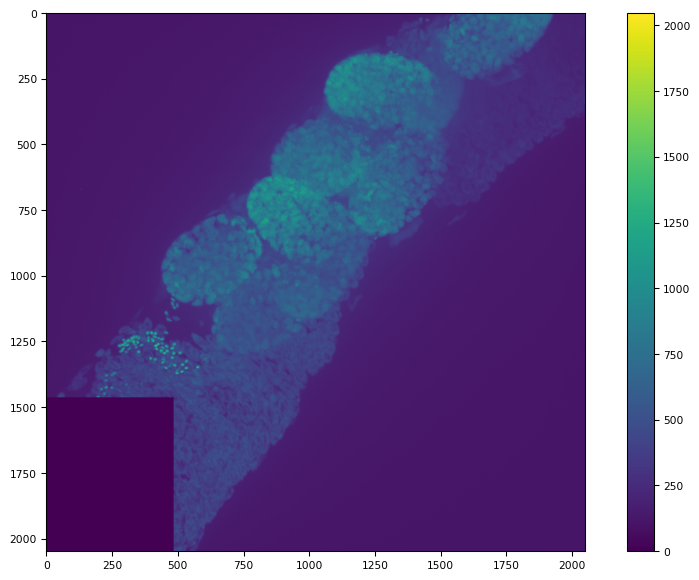

In [15]:
dapi3 = tiff3[:,2,:,:]
MIP3 = np.max(dapi3, axis = 0)
MIP3[len_x23-4096:,:4096-len_y23] = 0
tifffile.imshow(MIP3)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x2286f34a910>)

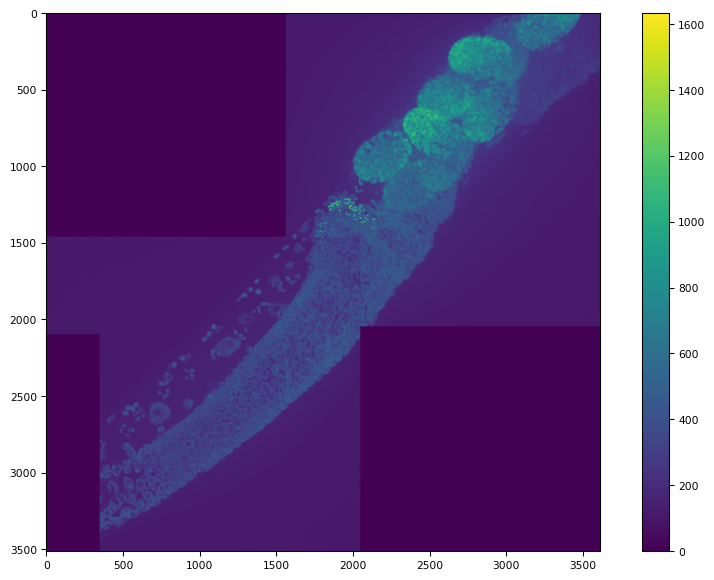

In [16]:
test23 = np.zeros((len_x23,len_y23))

test23[:2048,test23.shape[1]-2048:] = MIP3
test23[len_x23-4096 + 2048:,:2048] = MIP2
tifffile.imshow(test23)

In [17]:
tiff3_trimmed = tiff3.copy()
tiff3_trimmed[:,:,len_x23-4096:,:4096-len_y23] = 0

In [18]:
channel_sums3 = np.sum(tiff3_trimmed[:,:2,:,:], axis = (0, 2,3))


In [19]:
del tiff2
del tiff2_trimmed

## 34

In [20]:
file4 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos3.tif"
tiff4= imread(file4)


In [21]:
len_x34 = 3617
len_y34 = 3573

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22580013150>)

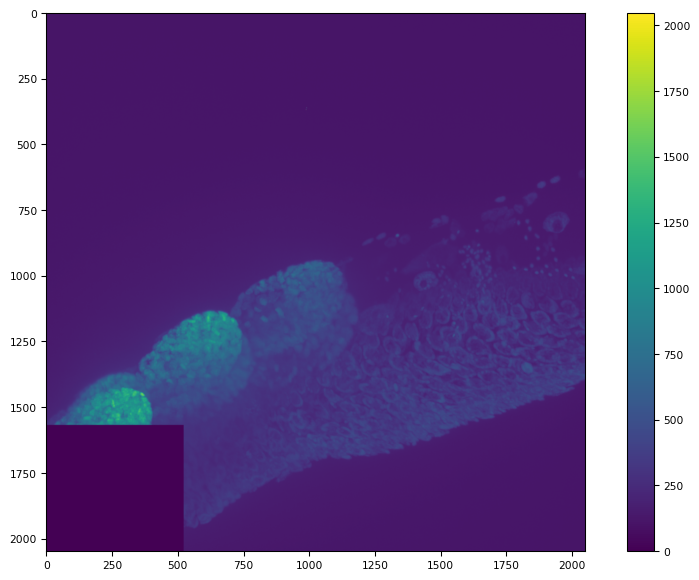

In [22]:
dapi4 = tiff4[:,2,:,:]
MIP4 = np.max(dapi4, axis = 0)
MIP4[len_x34-4096:,:4096-len_y34] = 0
tifffile.imshow(MIP4)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x2258152b150>)

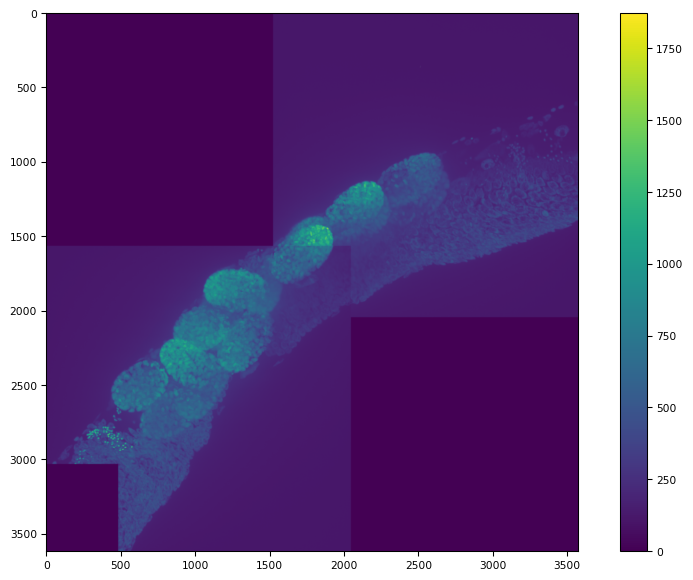

In [23]:
test34 = np.zeros((len_x34,len_y34))

test34[:2048,test34.shape[1]-2048:] = MIP4
test34[len_x34-4096 + 2048:,:2048] = MIP3
tifffile.imshow(test34)

In [24]:
tiff4_trimmed = tiff4.copy()
tiff4_trimmed[:,:,len_x34-4096:,:4096-len_y34] = 0

In [25]:
channel_sums4 = np.sum(tiff4_trimmed[:,:2,:,:], axis = (0,2,3))


In [26]:
del tiff3
del tiff3_trimmed

## 45

In [27]:
file5 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos4.tif"
tiff5= imread(file5)


In [28]:
len_x45 = 2625
len_y45 = 3632

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x2258161f990>)

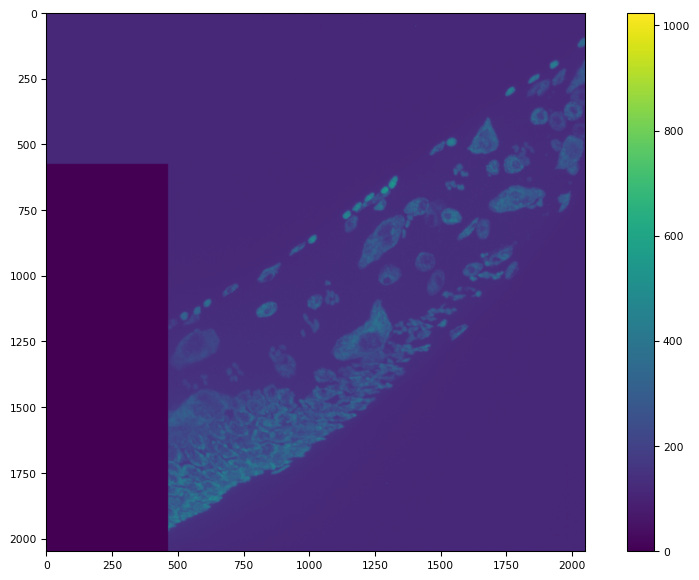

In [29]:
dapi5 = tiff5[:,2,:,:]
MIP5 = np.max(dapi5, axis = 0)
MIP5[len_x45-4096:,:4096-len_y45] = 0
tifffile.imshow(MIP5)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x2258df3b150>)

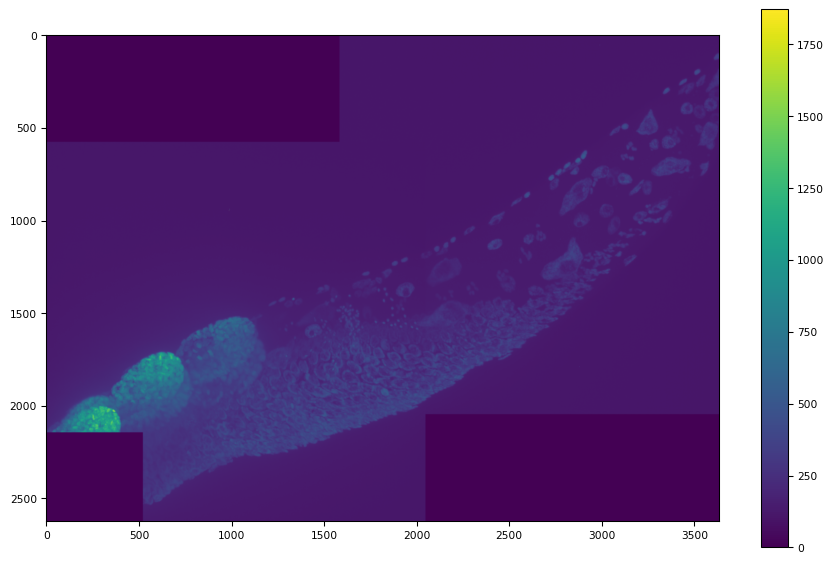

In [30]:
test45 = np.zeros((len_x45,len_y45))

test45[:2048,test45.shape[1]-2048:] = MIP5
test45[len_x45-4096 + 2048:,:2048] = MIP4
tifffile.imshow(test45)

In [31]:
tiff5_trimmed = tiff5.copy()
tiff5_trimmed[:,:,len_x45-4096:,:4096-len_y45] = 0

In [32]:
channel_sums5 = np.sum(tiff5_trimmed[:,:2,:,:], axis = (0,2,3))


In [33]:
del tiff4
del tiff4_trimmed

## 56

In [34]:
file6 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos5.tif"
tiff6= imread(file6)

In [35]:
len_x56 = 2669
len_y56 = 3092

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22581311b50>)

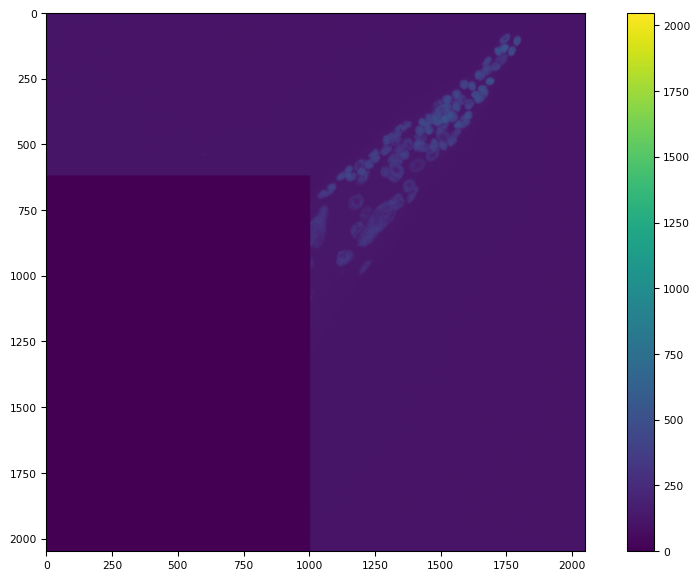

In [36]:
dapi6 = tiff6[:,2,:,:]
MIP6 = np.max(dapi6, axis = 0)
MIP6[len_x56-4096:,:4096-len_y56] = 0
tifffile.imshow(MIP6)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x225812f3150>)

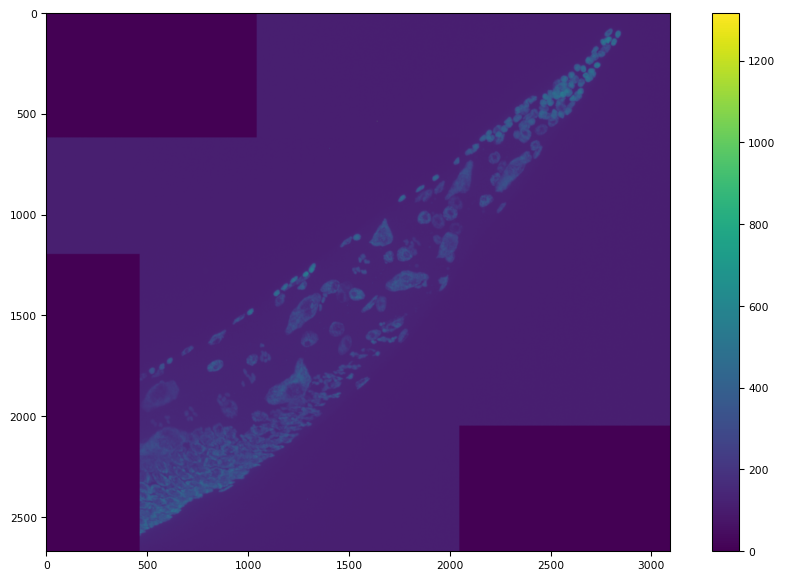

In [37]:
test56 = np.zeros((len_x56,len_y56))

test56[:2048,test56.shape[1]-2048:] = MIP6
test56[len_x56-4096 + 2048:,:2048] = MIP5
tifffile.imshow(test56)

In [38]:
tiff6_trimmed = tiff6.copy()
tiff6_trimmed[:,:,len_x56-4096:,:4096-len_y56] = 0

In [39]:
channel_sums6 = np.sum(tiff6_trimmed[:,:2,:,:], axis = (0,2,3))


In [40]:
del tiff5
del tiff5_trimmed
del tiff6
del tiff6_trimmed

# sum

In [41]:
channel_sums = channel_sums1 + channel_sums2 + channel_sums3 + channel_sums4 + channel_sums5

In [9]:
for hyb in range(2): #is it 20 or 21
    print(hyb)
    #DONE MANUALLY FOR POS 0 AND POS 1
    file1 = r"E:\data\CED3\processed\Zadjusted\Hyb{}\hyb_{}_pos0.tif".format(hyb, hyb)
    print(file1)
    
    
    file2 = r"E:\data\CED3\processed\Zadjusted\Hyb{}\hyb_{}_pos1.tif".format(hyb, hyb)
    print(file2)

   
    for i,f in enumerate([2,3,4,5]):
        file = r"E:\data\CED3\processed\Zadjusted\Hyb{}\hyb_{}_pos{}.tif".format(hyb, hyb, f)
        print(file)

0
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos0.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos1.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos2.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos3.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos4.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos5.tif
1
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos0.tif
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos1.tif
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos2.tif
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos3.tif
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos4.tif
E:\data\CED3\processed\Zadjusted\Hyb1\hyb_1_pos5.tif


# put in a loop without visualization: DAVID CHECK THATTHE NUMBER OF HYBS IN THE FOR LOOP IS CORRECT

In [3]:

def show_MIP(tiff_prev, tiff, len_x, len_y, orientation = 'up'):
    MIP = np.max(tiff[:,2,:,:], axis = 0)
    MIP_prev = np.max(tiff_prev[:,2,:,:], axis = 0)
    stitch = np.zeros((len_x,len_y))
    if orientation == 'up' or orientation == 'reverse':
        stitch[:2048,stitch.shape[1]-2048:] = MIP
        stitch[len_x-4096 + 2048:,:2048] = MIP_prev
    if orientation == 'down':
        stitch[len_x-4096 + 2048:,stitch.shape[1]-2048:] = MIP
        stitch[:2048,:2048] = MIP_prev
    tifffile.imshow(stitch)

def crop_pos10(tiff):
    c1 = (-50,tiff.shape[0], 1442,1128)
    c2 = (-80,-50, 1750,824)
    c3 = (-90,-80, 1920,562)
    pos10_crop = [c1,c2,c3]
    for c in pos10_crop:
        #tiff[c[0]:c[1],:,c[2]:,:c[3]] = 0
        tiff[c[0]:c[1],:,:c[3], c[2]:] = 0
    return tiff

def cp2_1(tiff):
    c1 = (802,1180)
    c2 = (1312,1526)
    crop = [c1,c2]
    for c in crop:
        tiff[:,:,:c[0], c[1]:] = 0
    return tiff
def cp2_2(tiff):
    c1 = (0,tiff.shape[0],0,250,1700,tiff.shape[0])
    crop = [c1]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff
def cp2_4(tiff):
    c1 = (1600,1680)
    crop = [c1]
    for c in crop:
        tiff[:,:,c[0]:, c[1]:] = 0
    return tiff
def cp2_5(tiff):
    c1 = (1858,188)
    tiff[:,:,1858:, :188] = 0
    tiff[:,:,:536, :] = 0
    return tiff
def cp3_6(tiff):
    c1 = (0,tiff.shape[0],1793,417)
    c2= (-11,tiff.shape[0],0,-1)
    crop = [c1,c2]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:, :c[3]] = 0
        #tiff[c[0]:c[1],:,:c[3] ,c[2]:] = 0

    return tiff
def cp3_7(tiff):
    c1 = (0,tiff.shape[0],0,846,1326,tiff.shape[3])
    c2 = (0,tiff.shape[0],756,1546,0,452)
    c3 = (0,tiff.shape[0],298,1004,0, 306)
    c4 = (0,50,620,970,0, 462)
    c5 = (50,tiff.shape[0],628,976, 0,402)
    c6 = (0,10,1580,-1, 360,1150)
    c7 = (10,tiff.shape[0],1660,tiff.shape[2], 360,1050)
    crop = [c1,c2,c3,c4,c5,c6,c7]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff
def cp3_8(tiff):
    c1 = (0,10,754,1080,0,142)
    c2 = (10,18,782,1080,0,102)
    crop = [c1,c2]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff
def cp3_9(tiff):
    c1 = (100,tiff.shape[0],1400,1800,792,tiff.shape[3])
    c2 = (89,100,1350,1800,880,tiff.shape[3])
    c3 = (0,89,1350,1800,990,tiff.shape[3])
    crop = [c1,c2,c3]
    for c in crop:
        tiff[c[0]:,:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff
def cp4_7(tiff):
    c1 = (0,tiff.shape[0],1190,tiff.shape[2],0,750)
    crop = [c1]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff
def cp4_8(tiff):
    c1 = (0,tiff.shape[0],1626,tiff.shape[2],1624,tiff.shape[3])
    crop = [c1]
    for c in crop:
        tiff[c[0]:c[1],:,c[2]:c[3], c[4]:c[5]] = 0
    return tiff

In [4]:
x = np.arange(10)
x[0:5],x[6:len(x)]

(array([0, 1, 2, 3, 4]), array([6, 7, 8, 9]))

In [5]:
worm1 = {'prefix':r"F:\data\CED3\processed\Full Worm_CED3_Pool1_AdjustedTiff", 'positions':[0,1,2,3,4,5], 'hybs':np.arange(0,18), 
              'dims': [(2684, 3746), (3512,3611), (3617,3573), (2625, 3632), (2669,3092)], 'all_channel_sums': [], 'special_crops':{}, 'special_orientation':{}}

In [14]:
worm2 = {'prefix':r"F:\Data\FullWorm\20250523_FULLWORM_CED3POOL2\Adjusted_tiff_NOZALIGNED",'positions':[0,1,2,3,4,5], 'hybs':np.arange(0,21), 
              'dims': [(3352, 3259), (3645,2670), (3746,3238), (3161, 2624), (2465,2648)], 'all_channel_sums': [], 
         'special_crops':{1:cp2_1, 2:cp2_2,4:cp2_4,5:cp2_5},'special_orientation':{1:'down',2:'down',3:'down',4:'down',5:'reverse'}}

In [16]:
worm3 = {'prefix':r"F:\Data\FullWorm\20250523_FULLWORM_CED3POOL2\Adjusted_tiff_NOZALIGNED",'positions':[6,7,8,9,10], 'hybs':np.arange(0,21), 
              'dims': [(3793, 2549), (2837,3086), (2068,3777), (3530, 3357)], 'all_channel_sums': [], 
         'special_crops':{10:crop_pos10, 6:cp3_6,7:cp3_7,8:cp3_8,9:cp3_9},'special_orientation':{7:'down', 8:'down'} }

In [18]:
worm4 = {'prefix':r"D:\data\CED3\processed\Full Worm_CED3_Pool1_AdjustedTiff",'positions':[11,10,9,8,7,6], 'hybs':np.arange(0,18), 
              'dims': [(2755, 3488),(3028, 3473), (2261,3834), (2333,3826), (2210, 3789)], 'all_channel_sums': [], 
         'special_crops':{7:cp4_7,8:cp4_8},'special_orientation':{7:'down', 6:'down'}}

WORM: 0
hyb: 0
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 1
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 2
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 3
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 4
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 5
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 6
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 7
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 8
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 9
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 10
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 11
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 12
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 13
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 14
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 15
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 16
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6
WORM: 0
hyb: 17
pos 11
pos 10
pos 9
pos 8
pos 7
pos 6


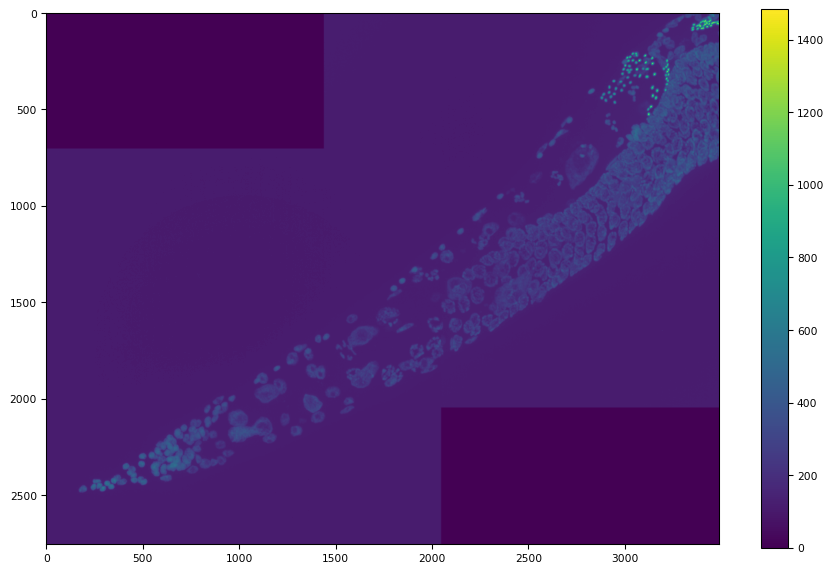

In [19]:
for w, worm in enumerate([worm4]):
    prefix = worm['prefix']
    first_hyb = True
    for hyb in worm['hybs']:
        print('WORM:',w)
        print('hyb:',hyb)
        pos =  worm['positions'][0]
        print('pos',pos)

        file1 = r"{}\pos{}\hyb_{}_pos{}.tif".format(prefix, pos, hyb, pos)
        tiff1 =imread(file1)
 
    
        if worm['special_crops'].get(pos) is not None:
            tiff1 = worm['special_crops'].get(pos)(tiff1)
        channel_sums = np.sum(tiff1[:,:2,:,:], axis = (0, 2,3))
        
      
        tiff_prev = tiff1#2
    
        xy = worm['dims']
        
        for i,pos in enumerate(worm['positions'][1:]): #skip first one
                
            print('pos',pos)
            file  = r"{}\pos{}\hyb_{}_pos{}.tif".format(prefix, pos, hyb, pos)
            tiff= imread(file)
            if worm['special_crops'].get(pos) is not None:
                tiff = worm['special_crops'].get(pos)(tiff)
            if worm['special_orientation'].get(pos) == 'reverse':
                temp = tiff
                tiff = tiff_prev
                tiff_prev = temp
            len_x = xy[i][0]
            len_y = xy[i][1]
            if worm['special_orientation'].get(pos) == 'down':
                tiff[:,:,:4096-len_x,:4096-len_y] = 0
            else:
                tiff[:,:,len_x-4096:,:4096-len_y] = 0
            if first_hyb:
                
                show_MIP(tiff_prev, tiff, len_x, len_y, worm['special_orientation'].get(pos, 'up'))
                first_hyb = False

            if worm['special_orientation'].get(pos) == 'reverse': #swap back
                temp = tiff
                tiff = tiff_prev
                tiff_prev = temp
            channel_sums = channel_sums + np.sum(tiff[:,:2,:,:], axis = (0, 2,3))
        
            del tiff_prev
        
            tiff_prev = tiff
        
        del tiff_prev
        
        worm['all_channel_sums'].append(channel_sums)
    try:
        pd.DataFrame(np.array(worm['all_channel_sums']), index = worm['hybs']).to_csv(r"E:\Data\CED3\Analysis\CED3 intensitysum Worm{}.csv".format(w+1))
    except:
        print('saving failed')

In [290]:
import pandas as pd

In [25]:
pd.DataFrame(all_channel_sums, index = np.arange(1,18)).to_csv(r"E:\data\CED3\Analysis\CED3 intensitysum Worm1.csv")

In [306]:
"E:\data\CED3\processed\Zadjusted\20250405_FULLWORM_CED3POOL1_pos0"

,0,1
1,464278786390,256306793681
2,252707488503,254004156383
3,249950092853,249674936668
4,250088641803,249164583387
5,250724068831,254652867484
6,251536785805,248437165473
7,252584366466,251155120702
8,250625530853,249045128696
9,252845325865,250026538769
10,250860883600,255940992067


# junk

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x27d51457830>)

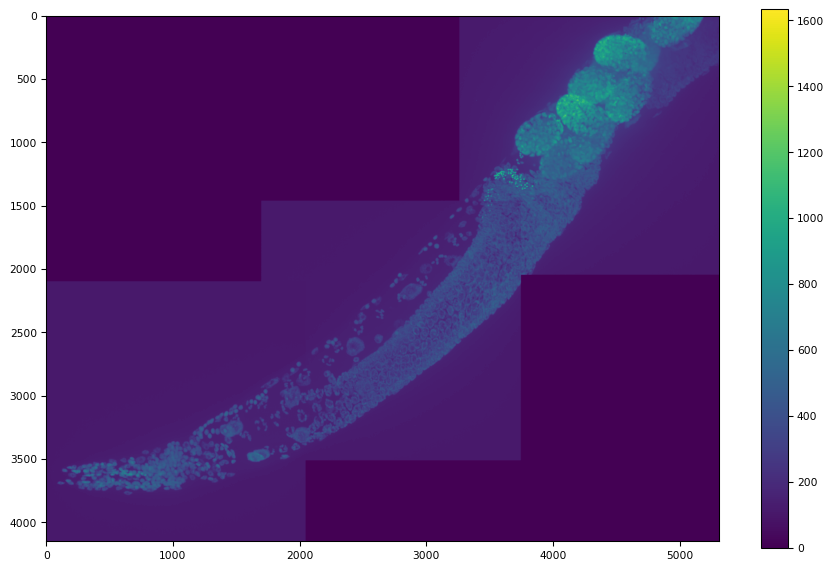

In [164]:
test = np.zeros((2048 +636+ len_x23 -2048 ,2048+ 2048 -350+ len_y23 -2048 ))

test[:2048,test.shape[1]-2048:] = MIP3
test[len_x23 -2048:len_x23,test.shape[1] -(len_y23 -2048) -2048:test.shape[1] - (len_y23 -2048)] = MIP2
test[-2048:,:2048] = MIP1
tifffile.imshow(test)

**confirm axes are correct**

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x277c366b4d0>)

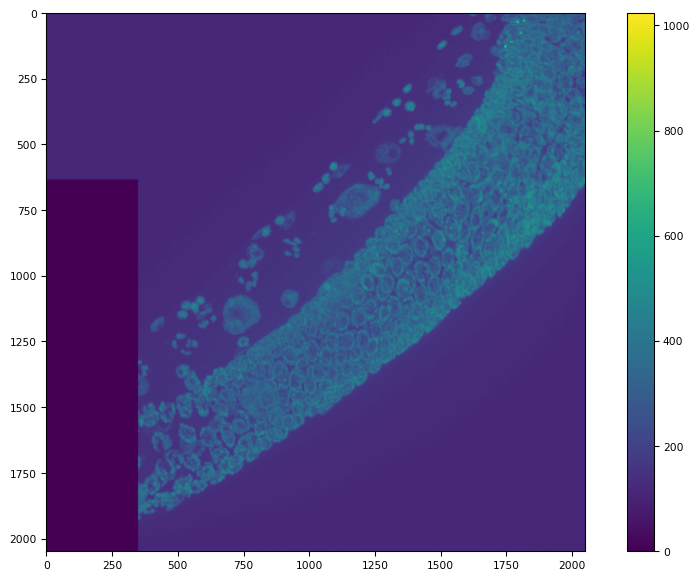

In [26]:
tiff2_trimmed = tiff2.copy()
tiff2_trimmed[:,:,636:,:350] = 0
MIP2 = np.max(tiff2_trimmed[:,2,:,:], axis = 0)
tifffile.imshow(MIP2)

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x2795df33020>)

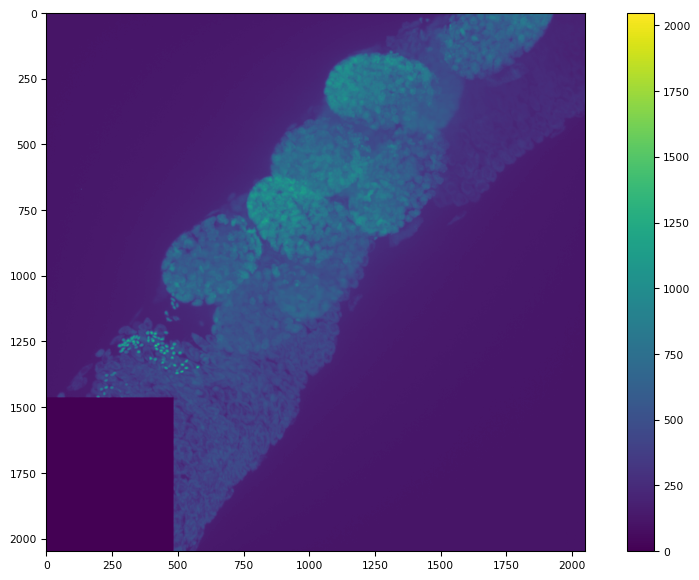

In [154]:
tiff3_trimmed = tiff3.copy()
tiff3_trimmed[:,:,len_x23-4096:,:4096-len_y23] = 0
MIP3 = np.max(tiff3_trimmed[:,2,:,:], axis = 0)
tifffile.imshow(MIP3)

In [32]:
channel_sums3 = np.sum(tiff3_trimmed[:,:2,:,:], axis = (2,3))
channel_sums2 = np.sum(tiff2_trimmed[:,:2,:,:], axis = (2,3))
channel_sums1 = np.sum(tiff1[:,:2,:,:], axis = (2,3))

In [ ]:
file1 = r"E:\data\CED3\processed\Zadjusted\20250405_FULLWORM_CED3POOL1_pos0\hyb_0_pos0.tif"
tiff1 =imread(file1)
file2 = r"E:\data\CED3\processed\Zadjusted\20250405_FULLWORM_CED3POOL1_pos1\hyb_0_pos1.tif"
tiff2= imread(file2)

# look at maximum intensity projections of DAPI channel. indices are: z, channel, x, y
#file 1 (far left side, no cropping needed)
dapi1 = tiff1[:,2,:,:]
MIP1 = np.max(dapi1, axis = 0)
tifffile.imshow(MIP1)
dapi2 = tiff2[:,2,:,:]

#file 2 (to the right of file 1, cropping needed for region overlapping with file 1)
MIP2 = np.max(dapi2, axis = 0)
MIP2[636:,:350] = 0 #fill overlapping region with 0's
tifffile.imshow(MIP2)

#visualize maximum intensity projections together to ensure the coordinates were combined correctly
test12 = np.zeros((2048+636,2*2048-350))
test12[:2048,test12.shape[1]-2048:] = MIP2
test12[636:,:2048] = MIP1
tifffile.imshow(test12)

#to avoid making a huge array with all the full images together, just make a copy of each image that needs to be cropped and fill the overlapping region with 0
#fill actual array with 0's in the overlapping region for image on the right side
tiff2_trimmed = tiff2.copy()
tiff2_trimmed[:,:,636:,:350] = 0
MIP2 = np.max(tiff2_trimmed[:,2,:,:], axis = 0)
tifffile.imshow(MIP2)

#sum the total intensities for channel 0 and channel 1
channel_sums1 = np.sum(tiff1[:,:2,:,:], axis = (2,3)).shape
channel_sums2 = np.sum(tiff2_trimmed[:,:2,:,:], axis = (2,3)).shape


In [47]:
!pip install chardet

   ---------------------------------------- 0.0/199.4 kB ? eta -:--:--
   ------ --------------------------------- 30.7/199.4 kB 1.4 MB/s eta 0:00:01
   ------------ -------------------------- 61.4/199.4 kB 825.8 kB/s eta 0:00:01
   ---------------------------------------- 199.4/199.4 kB 1.5 MB/s eta 0:00:00


In [48]:
with open(r"E:\data\CED3\processed\Zadjusted\Hyb0\dataset_coordiantes.xml", 'rb') as file:
    raw_data = file.read()
    import chardet
    encoding = chardet.detect(raw_data)['encoding']
    print(f"Detected encoding: {encoding}")

Detected encoding: ISO-8859-1


In [ ]:
"E:\data\CED3\processed\Zadjusted\Hyb0\dataset_coordiantes.xml"

In [49]:
import numpy as np
import xml.etree.ElementTree as ET
from tifffile import imread, imshow

import re

import xml.etree.ElementTree as ET

# Open the file with explicit UTF-8 encoding
with open(r"E:\data\CED3\processed\Zadjusted\Hyb0\dataset_coordiantes.xml", 'r', encoding='ISO-8859-1') as file:
    tree = ET.parse(file)
root = tree.getroot()

# Extract all ViewRegistrations (one per tile)
view_registrations = root.findall('.//ViewRegistration')

# Store cumulative X/Y translations for each tile
tile_positions = []

for registration in view_registrations:
    transforms = registration.findall('.//ViewTransform[@type="affine"]')
    total_x, total_y = 0.0, 0.0
    
    for transform in transforms:
        affine = transform.find('affine').text
        # Parse the affine matrix (last column is translation)
        values = list(map(float, affine.split()))
        tx, ty = values[3], values[7]  # Extract X/Y translations
        
        # Sum translations (assuming no rotation/scaling)
        total_x += tx
        total_y += ty
    
    tile_positions.append((total_x, total_y))

# Convert to relative pixel coordinates (assuming 0.101 µm/px XY resolution)
tile_positions_px = [(int(x / 0.101), int(y / 0.101)) for x, y in tile_positions]

In [52]:
def load_and_crop_tile(file_path, tile_idx, tile_positions_px):
    """Load a tile and crop overlapping regions based on coordinates."""
    print(file_path)
    tiff = imread(file_path)
    dapi = tiff[:, 2, :, :]  # Assuming channel 2 is DAPI
    
    # Get current tile's position
    current_x, current_y = tile_positions_px[tile_idx]
    
    # Compare with all other tiles to find overlaps
    for other_idx, (other_x, other_y) in enumerate(tile_positions_px):
        if other_idx == tile_idx:
            continue  # Skip self
        
        # Calculate relative positions
        dx = current_x - other_x
        dy = current_y - other_y
        
        # If tiles overlap in X/Y (assuming no Z overlap)
        if abs(dx) < 2048 and abs(dy) < 2048:
            # Define overlapping region to zero out
            x_start = max(0, dx)
            x_end = min(2048, 2048 + dx)
            y_start = max(0, dy)
            y_end = min(2048, 2048 + dy)
            
            # Zero out the overlapping region
            tiff[:, :, x_start:x_end, y_start:y_end] = 0
    
    return tiff

# Example usage for pos0 and pos1
file0 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos0.tif"
file1 = r"E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos1.tif"

tiff0 = load_and_crop_tile(file0, 0, tile_positions_px)
tiff1 = load_and_crop_tile(file1, 1, tile_positions_px)

# Sum intensities for channels 0 and 1 (non-DAPI)
channel_sums_file0 = np.sum(tiff0[:, :2, :, :], axis=(2, 3))
channel_sums_file1 = np.sum(tiff1[:, :2, :, :], axis=(2, 3))

E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos0.tif
E:\data\CED3\processed\Zadjusted\Hyb0\hyb_0_pos1.tif


In [ ]:
base_path = r"E:\data\CED3\processed\Zadjusted\20250405_FULLWORM_CED3POOL1_pos{}"
channel_sums = []

for tile_idx in range(6):  # Assuming 6 tiles (pos0 to pos5)
    file_path = base_path.format(tile_idx) + r"\hyb_0_pos{}.tif".format(tile_idx)
    tiff = load_and_crop_tile(file_path, tile_idx, tile_positions_px)
    channel_sums.append(np.sum(tiff[:, :2, :, :], axis=(2, 3)))  # Sum channels 0/1

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x277c36449b0>)

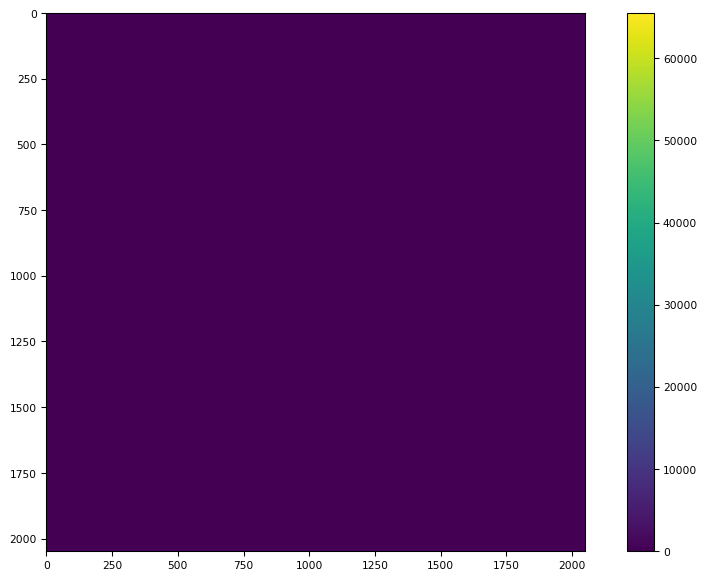

In [53]:
# Verify cropping (e.g., for pos1)
MIP1 = np.max(tiff1[:, 2, :, :], axis=0)
imshow(MIP1)

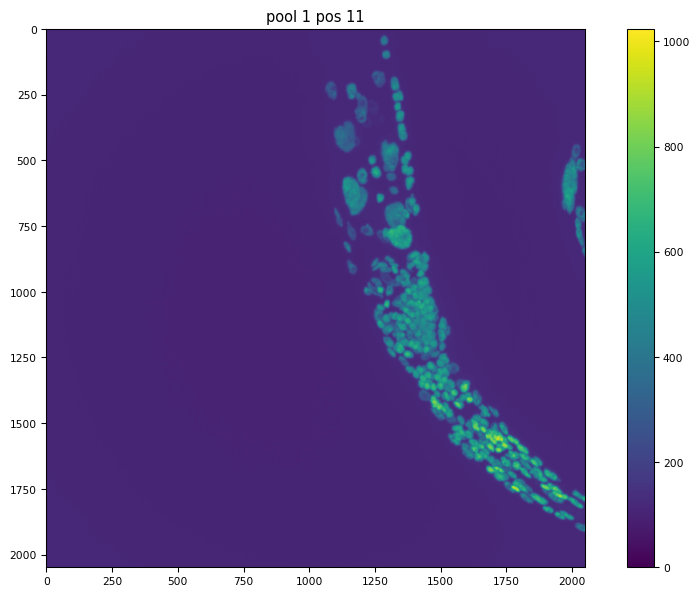

In [42]:
for i in [11]:
    file = r"G:\Data\malemarkers\processed\MG1_Pool1_20231109\Adjusted tiff\pos{}\hyb_0_pos{}.tif".format(i,i)
    tiff =imread(file)
    dapi = tiff[:,2,:,:]
    MIP = np.max(dapi, axis = 0)
    tifffile.imshow(MIP, title = 'pool 1 pos {}'.format(i))
    
    del tiff
    del dapi

In [31]:
file = r"D:\Data\FullWorm\20250523_FULLWORM_CED3POOL2\Adjusted_tiff_NOZALIGNED\pos10\hyb_0_pos10.tif"

In [85]:
tiff =imread(file)
tiff = np.swapaxes(tiff, 2,3)

In [86]:
c1 = (-50,-1, 1442,1128)
c2 = (-80,-51, 1750,824)
c3 = (-90,-81, 1920,562)
pos10_crop = [c1,c2,c3]

In [87]:
c1 = (-50,-1,1442,1128)
c2 = (-80,-51, 1750,824)
c3 = (-90,-81, 1920,562)
pos10_crop = [c1,c2,c3]

In [88]:
def crop_pos10():
    c1 = (-50,-1, 1442,1128)
    c2 = (-80,-51, 1750,824)
    c3 = (-90,-81, 1920,562)
    pos10_crop = [c1,c2,c3]
    for c in pos10_crop:
        tiff[c[0]:c[1],c[2]:,:c[3]] = 0


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x25b3fc7a9f0>)

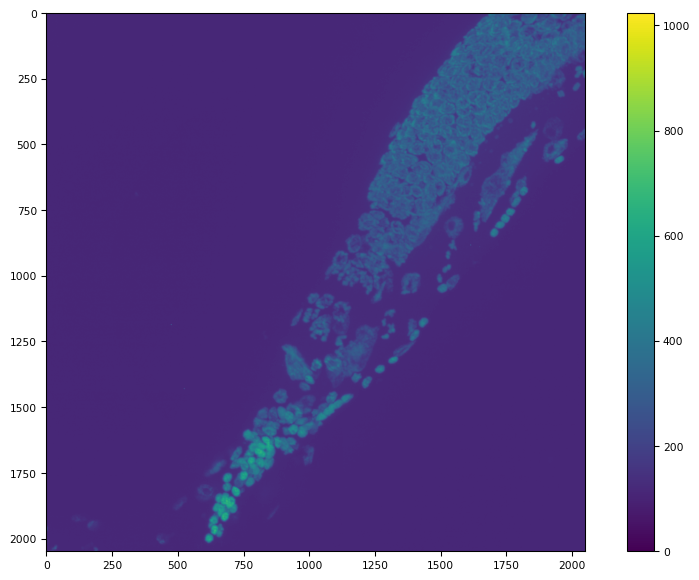

In [89]:
dapi = tiff[:,2,:,:]
for c in pos10_crop:
    dapi[c[0]:c[1],c[2]:,:c[3]] = 0
MIP = np.max(dapi, axis = 0)
tifffile.imshow(MIP)

In [1]:
import os
import glob
import tifffile as tiff

def check_tiff_shapes(folder):
    """
    Print the shape of every TIFF file in a folder.
    
    Parameters
    ----------
    folder : str
        Path to the folder containing TIFF files.
    """
    # Find all .tif and .tiff files
    tiff_files = glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff"))
    
    if not tiff_files:
        print("No TIFF files found in", folder)
        return
    
    for file in tiff_files:
        try:
            stack = tiff.imread(file)
            print(f"{os.path.basename(file)}: shape = {stack.shape}")
        except Exception as e:
            print(f"Error reading {file}: {e}")

In [6]:
# Example usage:
check_tiff_shapes(r"C:\Users\josed\Desktop\StarDIST_Training\CROP\CROP_RAW")

CROP1.tif: shape = (10, 400, 400)
CROP10.tif: shape = (10, 400, 400)
CROP100.tif: shape = (12, 400, 400)
CROP101.tif: shape = (12, 400, 400)
CROP102.tif: shape = (12, 400, 400)
CROP103.tif: shape = (12, 400, 400)
CROP104.tif: shape = (12, 400, 400)
CROP105.tif: shape = (12, 400, 400)
CROP106.tif: shape = (12, 400, 400)
CROP107.tif: shape = (12, 400, 400)
CROP108.tif: shape = (12, 400, 400)
CROP109.tif: shape = (12, 400, 400)
CROP11.tif: shape = (10, 400, 400)
CROP110.tif: shape = (12, 400, 400)
CROP111.tif: shape = (12, 400, 400)
CROP112.tif: shape = (12, 400, 400)
CROP113.tif: shape = (12, 400, 400)
CROP114.tif: shape = (12, 400, 400)
CROP115.tif: shape = (12, 400, 400)
CROP116.tif: shape = (12, 400, 400)
CROP117.tif: shape = (12, 400, 400)
CROP118.tif: shape = (12, 400, 400)
CROP119.tif: shape = (12, 400, 400)
CROP12.tif: shape = (12, 400, 400)
CROP120.tif: shape = (12, 400, 400)
CROP121.tif: shape = (12, 400, 400)
CROP122.tif: shape = (12, 400, 400)
CROP123.tif: shape = (12, 400, 40